# Probability of Default

In this notebook, we shall build a model to compute the probability of default ($PD$) for a potential borrower using logistic regression on our feature set. We will use 80% of the feature set to train the model and the other 20% to validate.

### Motivation

We first discuss the motivation. Under IFRS 9, the $ECL$ (expected credit loss) is given by the following formula: $$ECL=PD\cdot LGD \cdot EAD.$$ Here, $PD$ is the probability of default as previously mentioned, $LGD$ is the loss given a default and $EAD$ is the exposure at default.

So we wish to create a model that computes these terms individually and takes the product at the end. We shall first use logistic regression to estimate the $PD$.

### Splitting the Data

Let us import our feature set and the required Python packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#load feature set from 02
df = pd.read_csv('data/features.csv', index_col=0)
print(df.shape)

(99807, 25)


Now we separate the default flag, as this is what we are trying to predict with the model. We will later use this for validation.

In [2]:
#separate features from default flag
x = df.drop(columns=['default_flag'])
y = df['default_flag']
print(x.shape, y.shape)

(99807, 24) (99807,)


We split the data into 80% training data and 20% validation/test data. To do this, we use the `train_test_split` function, which splits the data into two groups at random. We choose a consistent seed such that the work may be reproduced using `random_state=42`. We also use `stratify=y` to ensure that the default rate is identical in both the training set and the validation set.

In [3]:
#split into 80% training and 20% validation
#stratify=y ensures default rate is consistent across both splits
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

#print details of split to verify
print(f'Training rows: {len(x_train)}, Test rows: {len(x_test)}')
print(f'Training default rate: {y_train.mean():.3f}')
print(f'Test default rate: {y_test.mean():.3f}')

Training rows: 79845, Test rows: 19962
Training default rate: 0.132
Test default rate: 0.132


So our data has been split as required.

## The Mathematics of Logistic Regression

Before we begin to train the model, we first explain the theory behind logistic regression. This will lead nicely into discussion of its limitations.

### The Logistic Function

A **logistic function** is a mathematical function $f:\mathbb{R}\to (0,L)$ of the form $$f(t)= \frac{L}{1+e^{-k(t-t_0)}}.$$ Here, $k$ is some arbitrary constant (representing the 'logistic growth rate') and $t_0$ is the $t$ value of the midpoint of the function (i.e. $f(0)$), which is chosen. One can see that $L$ is the upper limit of this function, since $e^{-k(t-t_0)}>0$ necessarily. So as $t\to\infty$ we have $f(t)\to \frac{L}{1}=L$, which can be easily verified. The logistic function is a type of **sigmoid function**, which, informally, is the name for functions that produce 'S-shaped' curves.

The **standard logistic function** $\sigma:\mathbb{R}\to (0,1)$ is the logistic function with $L=1$, $k=1$ and $t_0=0$, shown below for $-10\leq t\leq 10$. 

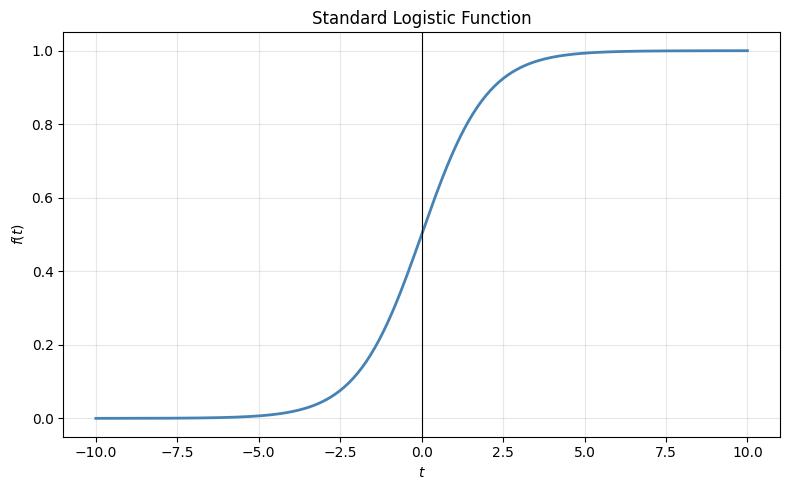

In [4]:
#standard logistic function
t = np.linspace(-10, 10, 300)
y = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 5))
plt.plot(t, y, color='steelblue', linewidth=2)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Standard Logistic Function")
plt.xlabel("$t$")
plt.ylabel("$f(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Independent Variables

Suppose now that we have $$t=\beta_0+\sum_{i=1}^{n}\beta_i x_i$$ in our standard logistic function. The $x_i$ are **independent variables** (in our case, these are equivalent to our features); the $\beta_i$ represent constant coefficients to be found.

### Computing the Probability

Given some features $x_1,\dots,x_n$ with known coefficients $\beta_0, \dots,\beta_n$ (note that $\beta_0$ does not have a corresponding feature) and $t$ as above, we can calculate the probability of some event $A$ occurring (when we come to apply logistic regression to the risk of default, then event $A$ will of course be the event of a default). We shall later return to the question of computing the coefficients $\beta_i$.

We first note that the standard logistic function at $t=\beta_0+\sum_{i=1}^{n}\beta_i x_i$ is given by $$\sigma(t)=\frac{1}{1+e^{-1(t-0)}}=\frac{1}{1+e^{-t}}=\frac{1}{1+e^{-(\beta_0+\beta_1 x_1 +\dots+\beta_n x_n)}}.$$ Then the probability of $A$, denoted $P(A)$, is given by $$P(A)=\sigma(t)=\frac{1}{1+e^{-(\beta_0+\beta_1 x_1 +\dots+\beta_n x_n)}}.$$ It is trivial to see that $0< P(A) < 1$ by nature of the standard logistic function.

### Odds Ratio

Let us rearrange the equation for the probability of $A$ to obtain $$e^{-t}=\frac{1}{P(A)}-1.$$ This then gives $$e^{-t}=\frac{1-P(A)}{P(A)} \implies e^{t}=\frac{P(A)}{1-P(A)}.$$ We can take the natural logarithm to get $$t=\beta_0+\sum_{i=1}^{n}\beta_i x_i=\ln(\frac{{P(A)}}{1-P(A)}).$$

We call $\frac{{P(A)}}{1-P(A)}$ the **odds ratio**, i.e. the ratio between the probability of $A$ occurring and the probability of $A$ not occurring. Similarly, $\ln(\frac{{P(A)}}{1-P(A)})$ is known as the **log-odds** of $A$; more commonly called the **logit** of $A$.

The interpretation of the logit is as follows: should the value of some feature $x_i$ increase by $1$, then the value of the logit increases by $\beta_i$. This can be easily seen from the above.

### Coefficient Estimation

We now conclude this section by discussing the estimation of the coefficicents $\beta_0,\dots,\beta_n$. It is first important to note that there is no algebraic solution to this problem, we must instead use numerical methods. Fortunately, thanks to the advent of modern technology, we are able to command the computer to do this for us. However, it is worth discussing for the purposes of understanding.

Suppose $A$ is an event that may or may not occur many times independently. For each instance of $A$, the features are distinct (although may be equal). Define $y_j$ as follows: $$y_j = \begin{cases} 1 & \text{if }A\text{ occurs,} \\ 0 & \text{if }A\text{ does not occur.} \end{cases}$$

For each instance $j$ of $A$ potentially occurring, we can then write $$P(y_j=y)=P(A)^y\cdot(1-P(A))^{1-y}.$$ Substituting $y=1$ or $y=0$ gives the correct probability.

We can write the probability of any given set of outcomes for $A$ across $m$ instances as the product $$\prod_{j=1}^{m}P(A)^{y_j}\cdot(1-P(A))^{1-y_j}.$$ We call this the **likelihood** for a 'dataset' (set of specific outcomes).

Now, let us assume we already have a 'dataset'. In other words, we already know the outcome of $A$ over $m$ separate instances. Taking $A$ as previously in this section, we recall that $$P(A)=\sigma(t)=\frac{1}{1+e^{-(\beta_0+\beta_1 x_1 +\dots+\beta_n x_n)}}$$ for known (variable) features $x_1,\dots, x_n$ and unknown coefficients $\beta_0,\dots, \beta_n$. We can work backwards to find our coefficients. We define the **log-likelihood** $\ell(\beta_0,\dots,\beta_n)$ by taking the natural logarithm of the likelihood as so: $$\ell(\beta_0,\dots,\beta_n)=\ln(\prod_{j=1}^{m}P(A)^{y_j}\cdot(1-P(A))^{1-y_j}).$$ Some manipulation using the standard laws of logarithms gives $$\ell(\beta_0,\dots,\beta_n)=\sum_{j=1}^{m}( y_j\ln P(A) + (1-y_j)\ln(1-P(A))).$$

We now make an assumption: we assume that our known outcome is the most likely outcome (since it is the outcome we acquired). So, we wish to estimate $\beta_0,\dots,\beta_n$ such that $\ell(\beta_0,\dots,\beta_n)$ is maximised. In order to maximise $\ell(\beta_0,\dots,\beta_n)$, we take the derivative with respect to each $\beta_i$,  $\frac{\partial\ell}{\partial \beta_i}$, and set to $0$ to give a set of equations $$\frac{\partial\ell}{\partial \beta_i}=0$$ for each $i$. One can show that the log-likelihood is globally concave and as such, the $0$ value of the first partial derivatives definitely maximise $\ell(\beta_0,\dots,\beta_n)$, although we shall not do so here for this is out of scope.

As mentioned previously, there is no algebraic solution to these equations and so they must be estimated using numerical methods. This is known as **logistic regression**. We shall use the `sklearn` Python library to perform this exercise for us.



## Model Training

Now that we understand the theory, we can begin to train our model. Let us perform logistic regression on our dataset. We first standardise each feature to put them on the same scale. The reason we do this is due to the massive disparity in the range of values each feature may take. To standardise, we adjust such that the mean and standard deviation of each feature is 0 and 1 respectively.


In [5]:
#StandardScaler standardises each feature to have mean 0 and standard deviation 1
scaler = StandardScaler()

#we fit_transform the training data, i.e. we calculate the mean/standard deviation for each feature then subtract the mean and divide by the standard deviation (to get 0 and 1)
x_train_scaled = scaler.fit_transform(x_train)

#we do not 'fit' the training data, we only transform using the mean and standard deviation from the training set
#if we were to fit, we would be using information from our test set in our training data
x_test_scaled = scaler.transform(x_test)

Now we train using logistic regression on the scaled training data. There are a few parameters to mention: `class_weight='balanced'` corrects for the training/test data imbalance and `max_iter=10000` allows for a significant amount of iterations of the optimisation process, improving the accuracy of the convergence.

In [6]:
model = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)
model.fit(x_train_scaled, y_train)
print('Model trained.')

Model trained.


Now we have trained our model, let us predict the probability of a default on each loan in the test set (the 20% we split). We then compare against the actual default rate observed in the test set.

In [7]:
#predict probability of default for each loan in the test set
#predict_proba returns two columns: probability of 0 and probability of 1
#we take the second column [:, 1] which is the probability of default
y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]

#we check against the actual
print(f'Mean predicted probability of default: {y_pred_proba.mean():.3f}')
print(f'Actual default rate in test set: {y_test.mean():.3f}')

Mean predicted probability of default: 0.450
Actual default rate in test set: 0.132


Our predicted probability of default and the actual default rate in the test set are vastly different. We must recalibrate. First, however, we shall assess the discriminatory power of our model.

## The Receiver Operating Characteristic Curve and the Gini Coefficient

Suppose we were to plot a curve of the false positive rate (those incorrectly identified as defaulters) against the true positive rate (those correctly identified) at each threshold between $0$ and $1$. For example, we might choose the threshold to be $0.5$, at which we take anyone with a predicted probability of $>0,5$ to have defaulted. We then compare with our actual results to obtain a point on the curve of the false positive rate against the true positive rate. We repeat for all thresholds between $0$ and $1$. We call this the **receiver operating characteristic (ROC) curve** and is shown below. We also draw a line representing a model that assigns probabilities at random, for reference.

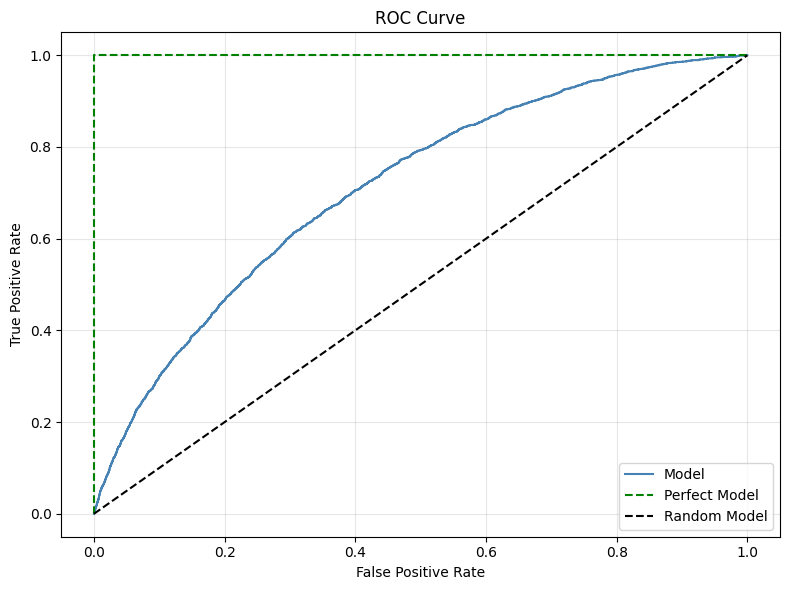

In [8]:
#compute the false positive rate, true positive rate at each threshold using the roc_curve function
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

#plot
plt.figure(figsize=(8, 6))

#the trained model curve
plt.plot(fpr, tpr, color='steelblue', linewidth=1.5, label='Model')

#straight up to (0,1) then across - represents a perfect model
plt.plot([0, 0, 1], [0, 1, 1], color='green', linewidth=1.5, linestyle='--', label='Perfect Model')

#the diagonal reference line — represents a random model
plt.plot([0, 1], [0, 1], color='black', linewidth=1.5, linestyle='--', label='Random Model')

#formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


If we calculate the area under the curve, it can give us information about the discriminatory power of our model, i.e. how well the model ranks the loans in terms of default probability. In a perfect model, every loan that defaulted is ranked higher than every loan that did not default. In an imperfect yet strong model, almost every loan that defaulted is ranked above almost every loan that did not default. The ROC curve of a perfect model, shown above, is one such that the true positive rate is $1.0$ at any theshold and that some threshold has been identified for which no false positives are identified. This is impossible in practice.

### The Gini Coefficient

Suppose that we choose one random defaulter and one random non-defaulter from the test data. What is the probability that the model correctly ranks the defaulter above the non-defaulter (i.e. it identifies the defaulter as more likely to default than the non-defaulter)? We can compute this by computing the area under our model curve. We shall not go into the specifics of why this works to contain our scope, despite it being an interesting exercise. For a model that is stronger than a random model, the area under the curve is necessarily between $0.5$ and $1$ (see the graph for a visual indication of this). The perfect model has an area under the curve of exactly $1$.

If we double the area under the curve and subtract $1$, we obtain a value between $0$ and $1$ instead (we have just applied a basic linear transformation). This is called the **Gini coefficient** and is a measure of the deterministic accuracy of a model. The closer to $1$ (the perfect model), the better.

Let us compute our Gini coefficient.

In [9]:
from sklearn.metrics import roc_auc_score

#compute area under the curve
auc = roc_auc_score(y_test, y_pred_proba)

#gini is a linear transformation of the area under the curve
gini = 2*auc - 1

print(f'Area Under the Curve: {auc:.3f}')
print(f'Gini Coefficient: {gini:.3f}')

Area Under the Curve: 0.712
Gini Coefficient: 0.424


Our Gini coefficient and ROC curve suggest that our model correctly ranks a randomly selected defaulter above a randomly selected non-defaulter a majority of the time (from the area under the curve). This suggests our model is of some value for ranking purposes. A Gini coefficient of above $0.4$ is acceptable for a first-draft model.

## Recalibration

Despite the above success, the question still remains as to how to address the massive disparity between the predicted probability of default (from our model) and the actual default rate. The answer lies in the calibration. Recall we used the parameter `class_weight='balanced'` when first training the model. This parameter reweights each outcome inversely proportional to the frequency of its entire class (i.e. default or non-default) across the whole training set. In our case, this means defaults are upweighted (being the minority) and non-defaults are downweighted. As a result, the model trains under the false impression that the classes are roughly equal in size. Whilst the adjustment was necessary due to the accuracy paradox affecting the identification of the ranking, there are better ways to calibrate that give us more accurate results for the probability estimate, as we shall see.

Below we have plotted calibration curve. This curve plots the mean predicted probability against the actual observed default rate across ten bins of equal size. We want this curve to be as close as possible to the shown perfect calibration curve. In the perfect curve representing a perfect model, loans would default at the predicted rate. We see that our curve sits far below this. The model is overpredicting the default risk due to the abovementioned parameter. However, the curve does increase in the correct direction, which aligns with our earlier computation of the Gini coefficient.


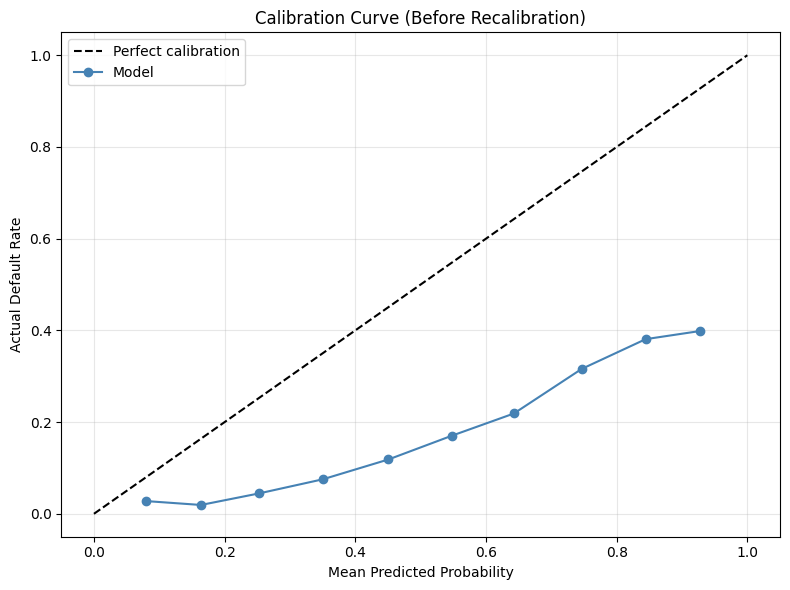

In [10]:
from sklearn.calibration import calibration_curve

#divide predictions into 10 bins and compare predicted vs actual default rate in each
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_proba, n_bins=10
)

plt.figure(figsize=(8, 6))

#perfect calibration line
plt.plot([0, 1], [0, 1], color='black', linewidth=1.5, linestyle='--', label='Perfect calibration')

#our model calibration
plt.plot(mean_predicted_value, fraction_of_positives, color='steelblue', linewidth=1.5, marker='o', label='Model')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Default Rate')
plt.title('Calibration Curve (Before Recalibration)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Platt Scaling

Due to the uniformity of our miscalibration (see curve), we choose **Platt scaling** to recalibrate. Platt scaling is used to fix the 'numbers' whilst leaving the ranking as is. The idea is to keep the 'pattern' but adjust the 'numbers' such that they are accurate. Each 'number' is adjusted in a manner such that it moves in-line with every other number. Platt scaling does is by fitting a new logistic regression with the original model's predicted probabilites (as opposed to the features) as input, then using the actual outcomes (default or non-default) as a target to calculate a corrected probability. Instead of multiple inputs as before, we only have one input in this logistical regression.

The other potential option for recalibration is isotonic regression. We prefer Platt scaling over isotonic regression here because the miscalibration is smooth and uniform across the full probability range, as visible in the calibration curve above. This makes a simple two-parameter transformation sufficient. Isotonic regression would offer more flexibility but risks overfitting given the relatively simple nature of the bias.

So we recalibrate. We pass the parameter `method='sigmoid'` to tell the library that we want to use Platt scaling. After recalibrating we regenerate the probabilities and output.

In [11]:
from sklearn.calibration import CalibratedClassifierCV

#fit Platt scaling on top of the existing trained model
#cv='prefit' tells sklearn the model is already trained — just fit the calibration layer
#method='sigmoid' implements Platt scaling
calibrated_model = CalibratedClassifierCV(model, cv=None, method='sigmoid')
calibrated_model.fit(x_train_scaled, y_train)

#generate recalibrated probabilities on the test set
y_pred_calibrated = calibrated_model.predict_proba(x_test_scaled)[:, 1]

#compare before and after
print(f'Mean predicted probability before calibration: {y_pred_proba.mean():.3f}')
print(f'Mean predicted probability after calibration:  {y_pred_calibrated.mean():.3f}')
print(f'Actual default rate:                           {y_test.mean():.3f}')

Mean predicted probability before calibration: 0.450
Mean predicted probability after calibration:  0.132
Actual default rate:                           0.132


This is now far more accurate. We plot the graph again.

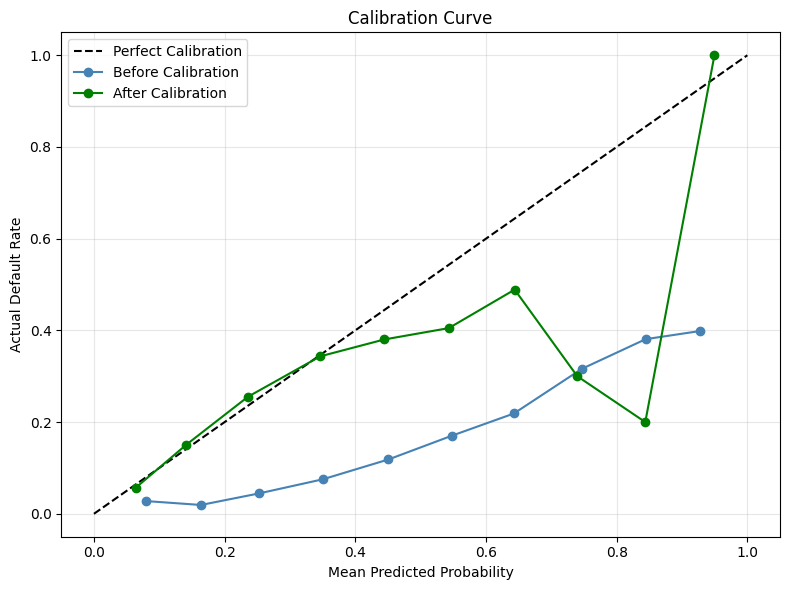

In [12]:
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(
    y_test, y_pred_calibrated, n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], color='black', linewidth=1.5, linestyle='--', label='Perfect Calibration')
plt.plot(mean_predicted_value, fraction_of_positives, color='steelblue', linewidth=1.5, marker='o', label='Before Calibration')
plt.plot(mean_predicted_value_cal, fraction_of_positives_cal, color='green', linewidth=1.5, marker='o', label='After Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Default Rate')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The erratic nature of the new curve after a mean predicted probability of $0.6$ is expected and is due to the very few loans with very high predicted probabilities (most loans that are very likely to default would be rejected before commencement) - thus producing noisy estimates that jump around in those bins. This adds credence to the accuracy of our recalibrated values as this is the behaviour we'd expect.

## Feature Importance

We can now extract the coefficients from the model, to evaluate the importance of each feature.

                                feature  coefficient
4                             sub_grade     1.500068
3                           installment     0.473174
1                                  term     0.183176
22         verification_status_Verified     0.120051
10                       inq_last_6mths     0.111209
21  verification_status_Source Verified     0.065966
15                            total_acc     0.059517
14                           revol_util     0.041126
11                             open_acc     0.034918
12                              pub_rec     0.028936
5                            emp_length     0.020182
23                         purpose_risk     0.012199
8                           delinq_2yrs     0.008774
7                                   dti     0.008238
17                 pub_rec_bankruptcies    -0.003055
20                  home_ownership_RENT    -0.009131
16                             mort_acc    -0.032808
19                   home_ownership_OWN    -0.

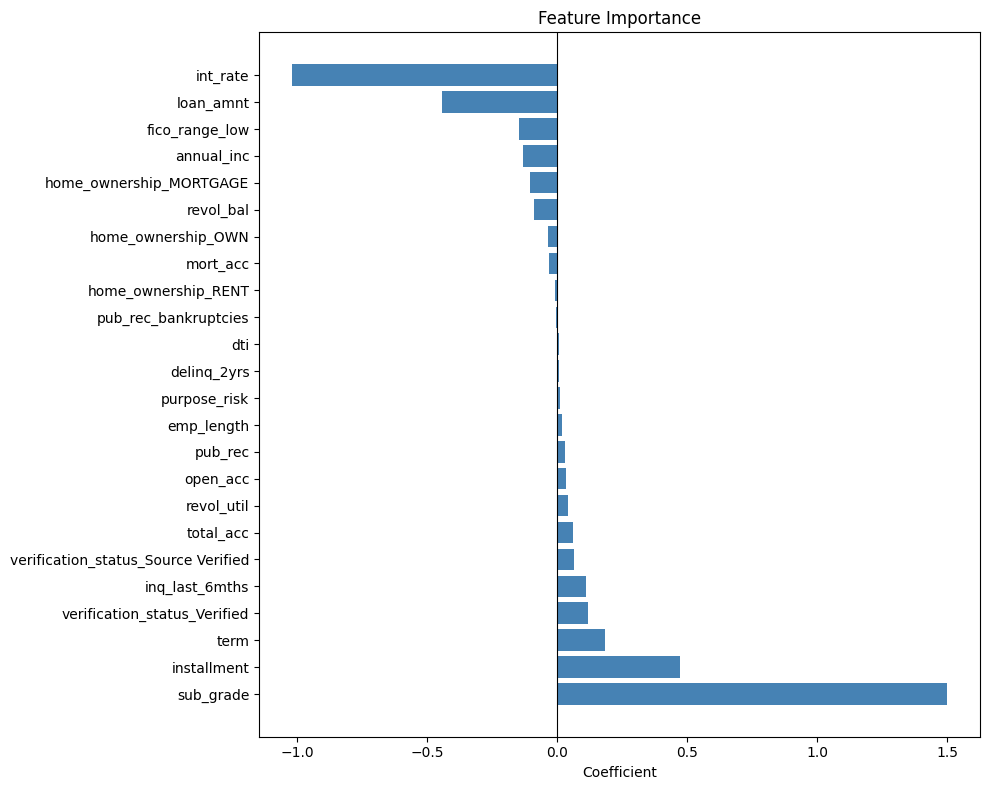

In [13]:
#extract coefficients from the original model
importance = pd.DataFrame({
    'feature': x_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(importance.to_string())

#plot
plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['coefficient'], color='steelblue')
plt.xlabel('Coefficient')
plt.title('Feature Importance')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

There are a couple of noteworthy observations here:
- The coefficient of the `int_rate` is $-1.019617$. On initial consideration, this may seem surprising. It should be so that those with higher interest rates are of greater risk. However, if you consider the profile of those who take high interest loans, they often are more consistent with payments so as to not suffer the accrual of significant interest. It is important to remember that borrowers will be considerate of their personal risk too. A high interest loan without the means to repay is a much greater risk than a low interest loan. Also consider that lenders are less inclined to give high interest loans to those who they deem risky, so many possible defaulters due to high interest rates never had the chance to be a part of the dataset.
- In a similar vein, those who are able to take out larger loans (`loan_amnt`) are more likely to have financial stability. They also are likely to have an easily identifiable purpose for the loan, rather than just for some cash flow relief, such is the case with many small loans.
- Interestingly, despite our attempts to categorise `purpose` into risk levels, it ended up have essentially no bearing on the probabilities. This suggests that either the purpose of the loan is somewhat irrelevant to the risk of default, or that we categorised inaccurately. It would be interesting to later revisit and alter these categories, to see if the coefficient changes significantly.
- LendingClub's established risk grading appears to be a pretty reliable indicator - this feature (`sub_grade`) has the greatest coefficient.
- Higher monthly repayments (`installment`) correlates with higher risk. Similarly, longer loan terms (`term`) correlates with higher risk, but less so. This makes sense, as a longer time provides more opportunities for a borrower to run into financial difficulty.

Regarding `int_rate` and `sub_grade`, if we print the means of all the interest rates across each subgrade, we obtain the following output:


In [14]:
#output means of interest rates across each subgrade
print(df.groupby('sub_grade')['int_rate'].mean().to_string())

sub_grade
1      5.595373
2      6.549525
3      7.092381
4      7.563723
5      8.200511
6      9.075443
7      9.975986
8     10.701412
9     11.369436
10    12.020678
11    12.787600
12    13.525108
13    14.117383
14    14.885275
15    15.764237
16    16.641172
17    17.592955
18    18.366768
19    19.102399
20    20.105253
21    20.270927
22    21.100519
23    21.938734
24    22.822288
25    24.109799
26    24.522981
27    25.074770
28    25.865976
29    26.341004
30    27.176000
31    27.819200
32    27.883929
33    27.714231
34    28.307614
35    29.069241


We see that interest rates are correlated with the `sub_grade`. This makes sense, as those who are more likely to default will be given higher interest rates due to the increased risk for the lender. In future, we should have made this consideration during feature engineering and perhaps removed `int_rate`.

We now save our model.

In [15]:
#save test set with calibrated predicted probabilities for use in 04 and 05
results = x_test.copy()
results['default_flag'] = y_test
results['pd_predicted'] = y_pred_calibrated
results.to_csv('data/pd_results.csv', index=True)
print(f'Saved {len(results)} rows to pd_results.csv')

Saved 19962 rows to pd_results.csv
